In [1]:
using LinearAlgebra
using LinearOperators
using SparseArrays

In [2]:
function get_1d_laplace_op_matrix(n)
	off = ones(n-1)
	diag = ones(n)
	spdiagm(-1 => off, 0 => -2diag, 1 => off)
end

get_1d_laplace_op_matrix (generic function with 1 method)

In [3]:
# L
# E L, L E
# E E L, E L E, L E E
# E E E L, E E L E, E L E E, L E E E
# (E E E L), (E E L) (E), (E L) (E E), (L) (E E E)
# E ... E L = L of size n^(k+1) if E is there k times
function get_laplace_op_matrix(n, d)
	L_full = get_1d_laplace_op_matrix(n^d)
	for k in 1:(d-1)
		L = get_1d_laplace_op_matrix(n^(d-k))
		size = n^k
		E = sparse(I, size, size)
		L_full += kron(L, E)
	end
	L_full
end

# 4 points, 3 dims
#get_laplace_op_matrix(4, 3)

get_laplace_op_matrix (generic function with 1 method)

In [4]:
#Matrix(L_full)

## define RHS and solve using different methods

$\Delta u = f \:\:\text{on}\:\:\Omega$

$u = g \:\:\text{on}\:\:\partial\Omega$

supp 1D:

$ \partial u / \partial x \approx \frac{u(x+h/2) - u(x-h/2)}{h}$

$\Delta u(x) \approx \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}$

$ u_{i-1} - 2u_i + u_{i+1} = h^2 f_i$

$ i = 0,1,...,n,n+1 $

boundary: $\:i=0, \:i=n+1 $

we know $\:u_0, \:u_{n+1}\:$ from BC

we need $n$ equation for $n$ unknowns ($u_1,...,u_n$)

$ u_0 - 2u_1 + u_2 = h^2 f_1 $

$ u_1 - 2u_2 + u_3 = h^2 f_2 $

...

$ u_{n-2} - 2u_{n-1} + u_{n} = h^2 f_{n-1} $

$ u_{n-1} - 2u_n + u_{n+1} = h^2 f_n $

we get

$ L U = F $

where
- $L$ matrix of size $n \times n$
- $U = (u_1, u_2, ..., u_{n-1}, u_n)$
- $F = h^2(f_1, f_2, ..., f_{n-1}, f_n) - (u_0, 0, ..., 0, u_{n+1})$

In [5]:
n = 100
d = 2
N = n^d

10000

In [6]:
h = 1 / (n+1)

0.009900990099009901

In [7]:
function u_analytic_fun(x)
    #prod(x)*prod(1 .- x)
    prod(sin.(pi*x))
end

function f_fun(x)
    d = length(x)
    -d*pi^2 * prod(sin.(pi*x))
end

f_fun (generic function with 1 method)

### fiddling around

In [8]:
v = Vector([1,2,3])
v, f_fun(v)

([1, 2, 3], 3.262907826717048e-46)

In [9]:
v = Vector([Vector([1,2,3]), Vector([1,1,1])])
v, f_fun.(v)

([[1, 2, 3], [1, 1, 1]], [3.262907826717048e-46, -5.438179711195081e-47])

In [10]:
xs = [range(h, 1-h; length=n) for _ in 1:d]

2-element Vector{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}:
 0.009900990099009901:0.009900990099009901:0.9900990099009901
 0.009900990099009901:0.009900990099009901:0.9900990099009901

In [15]:
n,d

(100, 2)

In [22]:
Iterators.product(xs...)

Base.Iterators.ProductIterator{Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}}((0.009900990099009901:0.009900990099009901:0.9900990099009901, 0.009900990099009901:0.009900990099009901:0.9900990099009901))

In [12]:
coords = collect(Iterators.product(xs...))

100×100 Matrix{Tuple{Float64, Float64}}:
 (0.00990099, 0.00990099)  (0.00990099, 0.019802)  …  (0.00990099, 0.990099)
 (0.019802, 0.00990099)    (0.019802, 0.019802)       (0.019802, 0.990099)
 (0.029703, 0.00990099)    (0.029703, 0.019802)       (0.029703, 0.990099)
 (0.039604, 0.00990099)    (0.039604, 0.019802)       (0.039604, 0.990099)
 (0.049505, 0.00990099)    (0.049505, 0.019802)       (0.049505, 0.990099)
 (0.0594059, 0.00990099)   (0.0594059, 0.019802)   …  (0.0594059, 0.990099)
 (0.0693069, 0.00990099)   (0.0693069, 0.019802)      (0.0693069, 0.990099)
 (0.0792079, 0.00990099)   (0.0792079, 0.019802)      (0.0792079, 0.990099)
 (0.0891089, 0.00990099)   (0.0891089, 0.019802)      (0.0891089, 0.990099)
 (0.0990099, 0.00990099)   (0.0990099, 0.019802)      (0.0990099, 0.990099)
 (0.108911, 0.00990099)    (0.108911, 0.019802)    …  (0.108911, 0.990099)
 (0.118812, 0.00990099)    (0.118812, 0.019802)       (0.118812, 0.990099)
 (0.128713, 0.00990099)    (0.128713, 0.019802)     

In [13]:
collect(coords[1])

InterruptException: InterruptException:

In [ ]:
[collect(coords[1]), collect(coords[2])]

2-element Vector{Vector{Float64}}:
 [0.009900990099009901, 0.009900990099009901]
 [0.019801980198019802, 0.009900990099009901]

In [ ]:
f_fun.([collect(coords[1]), collect(coords[2])])

2-element Vector{Float64}:
 -0.019091791043757085
 -0.03816511201270312

In [ ]:
#grid_points_as_1d_vect = [collect(x) for x in coords[1:end]]
#f_fun.(grid_points_as_1d_vect)

### here we go

In [ ]:
function get_grid_points_as_1d_vect(n, d)
    a = 0
    b = 1
    h = 1/(n+1)
    xs = [range(h, 1-h; length=n) for _ in 1:d]
    coords = collect(Iterators.product(xs...))
    [collect(x) for x in coords[1:end]]
end
#f.(grid_points_as_1d_vect)

get_grid_points_as_1d_vect (generic function with 1 method)

In [ ]:
n^d

10000

In [ ]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [ ]:
U_analytic = u_analytic_fun.(grid_points_as_1d_vect);

In [ ]:
f = f_fun.(grid_points_as_1d_vect);
F = h^2 * f;

In [ ]:
L = get_laplace_op_matrix(n,d);

In [ ]:
Matrix(L);

In [ ]:
using IterativeSolvers
U_cg = cg(L, F)

10000-element Vector{Float64}:
 0.01928132630789413
 0.02633233541903
 0.029419758808380887
 0.031039314542434384
 0.03203835238350517
 0.03274289792281522
 0.0332944641374758
 0.03376132516090135
 0.034179370023113255
 0.03456873581498859
 0.03494125564067625
 0.03530408418547458
 0.03566159320233715
 ⋮
 0.0353040841854746
 0.03494125564067628
 0.0345687358149886
 0.03417937002311324
 0.0337613251609013
 0.03329446413747585
 0.03274289792281526
 0.03203835238350517
 0.03103931454243434
 0.02941975880838084
 0.026332335419029986
 0.019281326307894094

In [ ]:
U_direct = L \ F;

In [ ]:
#using CairoMakie
#CairoMakie.activate!()

In [ ]:
length(U_cg)

10000

In [ ]:
z = [U_cg[i*n+j] for i in 0:(n-1), j in 1:n]

100×100 Matrix{Float64}:
 0.0192813  0.0263323  0.0294198  …  0.0378582  0.0393133  0.0425209
 0.0507911  0.0566245  0.0603018     0.0749975  0.0768704  0.0799773
 0.0847339  0.0890654  0.0924599     0.111367   0.113186   0.11578
 0.119096   0.122432   0.125407      0.147098   0.148714   0.150857
 0.153431   0.156144   0.158764      0.182314   0.183701   0.185493
 0.187619   0.18993    0.192285   …  0.217094   0.218266   0.219786
 0.22161    0.223651   0.225816      0.251483   0.25246    0.253764
 0.25537    0.257222   0.259253      0.285497   0.2863     0.287429
 0.288869   0.290584   0.292521      0.319139   0.319786   0.320766
 0.322077   0.32369    0.325563      0.352398   0.352904   0.353758
 0.354963   0.356499   0.358329   …  0.385261   0.385636   0.386379
 0.387497   0.388975   0.390778      0.417706   0.417962   0.418606
 0.41965    0.421082   0.422869      0.449711   0.449855   0.45041
 ⋮                                ⋱                        
 0.418606   0.417962   0.417706

In [ ]:
z = [u_analytic_fun(Vector([xi,yi])) for xi in x, yi in y]

11×11 Matrix{Float64}:
 0.0  0.0          0.0          0.0         …  0.0          0.0
 0.0  0.0954915    0.181636     0.25           0.0954915    3.78437e-17
 0.0  0.181636     0.345492     0.475528       0.181636     7.19829e-17
 0.0  0.25         0.475528     0.654508       0.25         9.9076e-17
 0.0  0.293893     0.559017     0.769421       0.293893     1.16471e-16
 0.0  0.309017     0.587785     0.809017    …  0.309017     1.22465e-16
 0.0  0.293893     0.559017     0.769421       0.293893     1.16471e-16
 0.0  0.25         0.475528     0.654508       0.25         9.9076e-17
 0.0  0.181636     0.345492     0.475528       0.181636     7.19829e-17
 0.0  0.0954915    0.181636     0.25           0.0954915    3.78437e-17
 0.0  3.78437e-17  7.19829e-17  9.9076e-17  …  3.78437e-17  1.49976e-32

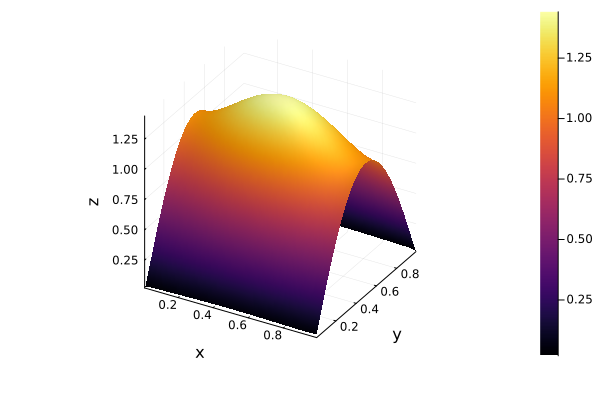

In [ ]:
using Plots

# Create a grid
x = y = h:h:(1-h)
z = [U_analytic[i*n+j] for i in 0:(n-1), j in 1:n]
z = [U_cg[i*n+j] for i in 0:(n-1), j in 1:n]
z = [U_direct[i*n+j] for i in 0:(n-1), j in 1:n]
#z = [F[i*n+j] for i in 0:(n-1), j in 1:n]

# Make the surface plot
surface(x, y, z, xlabel="x", ylabel="y", zlabel="z")

In [ ]:
U_analytic - U_direct;

In [ ]:
U_cg - U_direct;

In [ ]:
#using GLMakie
#GLMakie.activate!()
#
## Create a grid
#x = range(-5, 5, length=100)
#y = range(-5, 5, length=100)
#z = [sin(xi*yi) for xi in x, yi in y]
#
## 3D surface plot
#surface(x, y, z)
#Axis3(surface(x, y, z), xlabel="x", ylabel="y", zlabel="sin(x*y)")


In [ ]:
#grid_points = collect(range(h,1-h, length=n));
#scatter(grid_points, U_analytic, color=:gray0)
#lines!(grid_points, U_cg, color=:gray0)
#current_figure()

In [ ]:
#n_trials = 8
#n_mult = 8
#max_jacobi = zeros(n_trials)
#max_gs = zeros(n_trials)
#max_direct = zeros(n_trials)
#
#for i in 1:n_trials
#    n = n_mult*i
#    h = 1/(n+1)
#    grid_points = collect(range(h,1-h, length=n))
#    L = get_laplace_op_matrix(n)
#    F = h^2 * f_fun(grid_points)
#    U_jacobi = jacobi(L, F)
#    U_gs = gauss_seidel(L, F; maxiter=100)
#    U_direct = L \ F
#
#    max_jacobi[i] = maximum(U_jacobi)
#    max_gs[i] = maximum(U_gs)
#    max_direct[i] = maximum(U_direct)
#end